# Image slicing test scene

This notebook creates a 10k x 10k synthetic ocean scene, inserts the original image without modifying its pixels, verifies the result, and visualizes local and contextual tiles.

In [ ]:
from pathlib import Path
import hashlib
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display
from PIL import Image
from diffusers import StableDiffusionInpaintPipeline

Image.MAX_IMAGE_PIXELS = None

PROJECT_ROOT = Path("/home/irdorat/ML_comp")
ORIGINAL_PATH = (
    PROJECT_ROOT
    / "data/test/01-PAN-20240420-113-325-L00000010882-CCD3_5_crop7.jpg"
)
OUTPUT_PATH = PROJECT_ROOT / "data/test/gen_image2_controlled_10000x10000.png"
MODEL_CACHE = PROJECT_ROOT / "models/pretrained/huggingface-cache"

FINAL_SIZE = 10_000
GEN_TILE_SIZE = 512
GEN_OVERLAP = 0.25
GEN_STRIDE = int(GEN_TILE_SIZE * (1 - GEN_OVERLAP))
STRIP_WIDTH = 1024

TILE_SIZE = 800
OVERLAP = 0.20
STRIDE = int(TILE_SIZE * (1 - OVERLAP))

/home/irdorat/miniconda3/envs/ML_comp/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def calculate_positions(image_size: int, window_size: int, stride: int) -> list[int]:
    if image_size <= window_size:
        return [0]

    positions = list(range(0, image_size - window_size + 1, stride))
    last_position = image_size - window_size
    if positions[-1] != last_position:
        positions.append(last_position)
    return positions


def make_blend_weights(size: int, overlap: float) -> np.ndarray:
    edge = max(1, int(size * overlap))
    axis = np.ones(size, dtype=np.float32)
    ramp = np.linspace(0.01, 1.0, edge, dtype=np.float32)
    axis[:edge] = ramp
    axis[-edge:] = ramp[::-1]
    return np.outer(axis, axis)


def pixel_hash(image: Image.Image) -> str:
    return hashlib.sha256(np.asarray(image).tobytes()).hexdigest()

In [3]:
image_path = OUTPUT_PATH
with Image.open(image_path) as image:
    image_width, image_height = image.size

x_positions = calculate_positions(image_width, TILE_SIZE, STRIDE)
y_positions = calculate_positions(image_height, TILE_SIZE, STRIDE)
tile_coordinates = [
    {
        "tile_id": tile_id,
        "x1": x,
        "y1": y,
        "x2": x + TILE_SIZE,
        "y2": y + TILE_SIZE,
    }
    for tile_id, (y, x) in enumerate(
        (y, x) for y in y_positions for x in x_positions
    )
]

print(f"Image: {image_width}x{image_height}")
print(f"Stride: {STRIDE}; tiles: {len(tile_coordinates)}")
print("First:", tile_coordinates[0])
print("Last:", tile_coordinates[-1])

Image: 10000x10000
Stride: 640; tiles: 256
First: {'tile_id': 0, 'x1': 0, 'y1': 0, 'x2': 800, 'y2': 800}
Last: {'tile_id': 255, 'x1': 9200, 'y1': 9200, 'x2': 10000, 'y2': 10000}


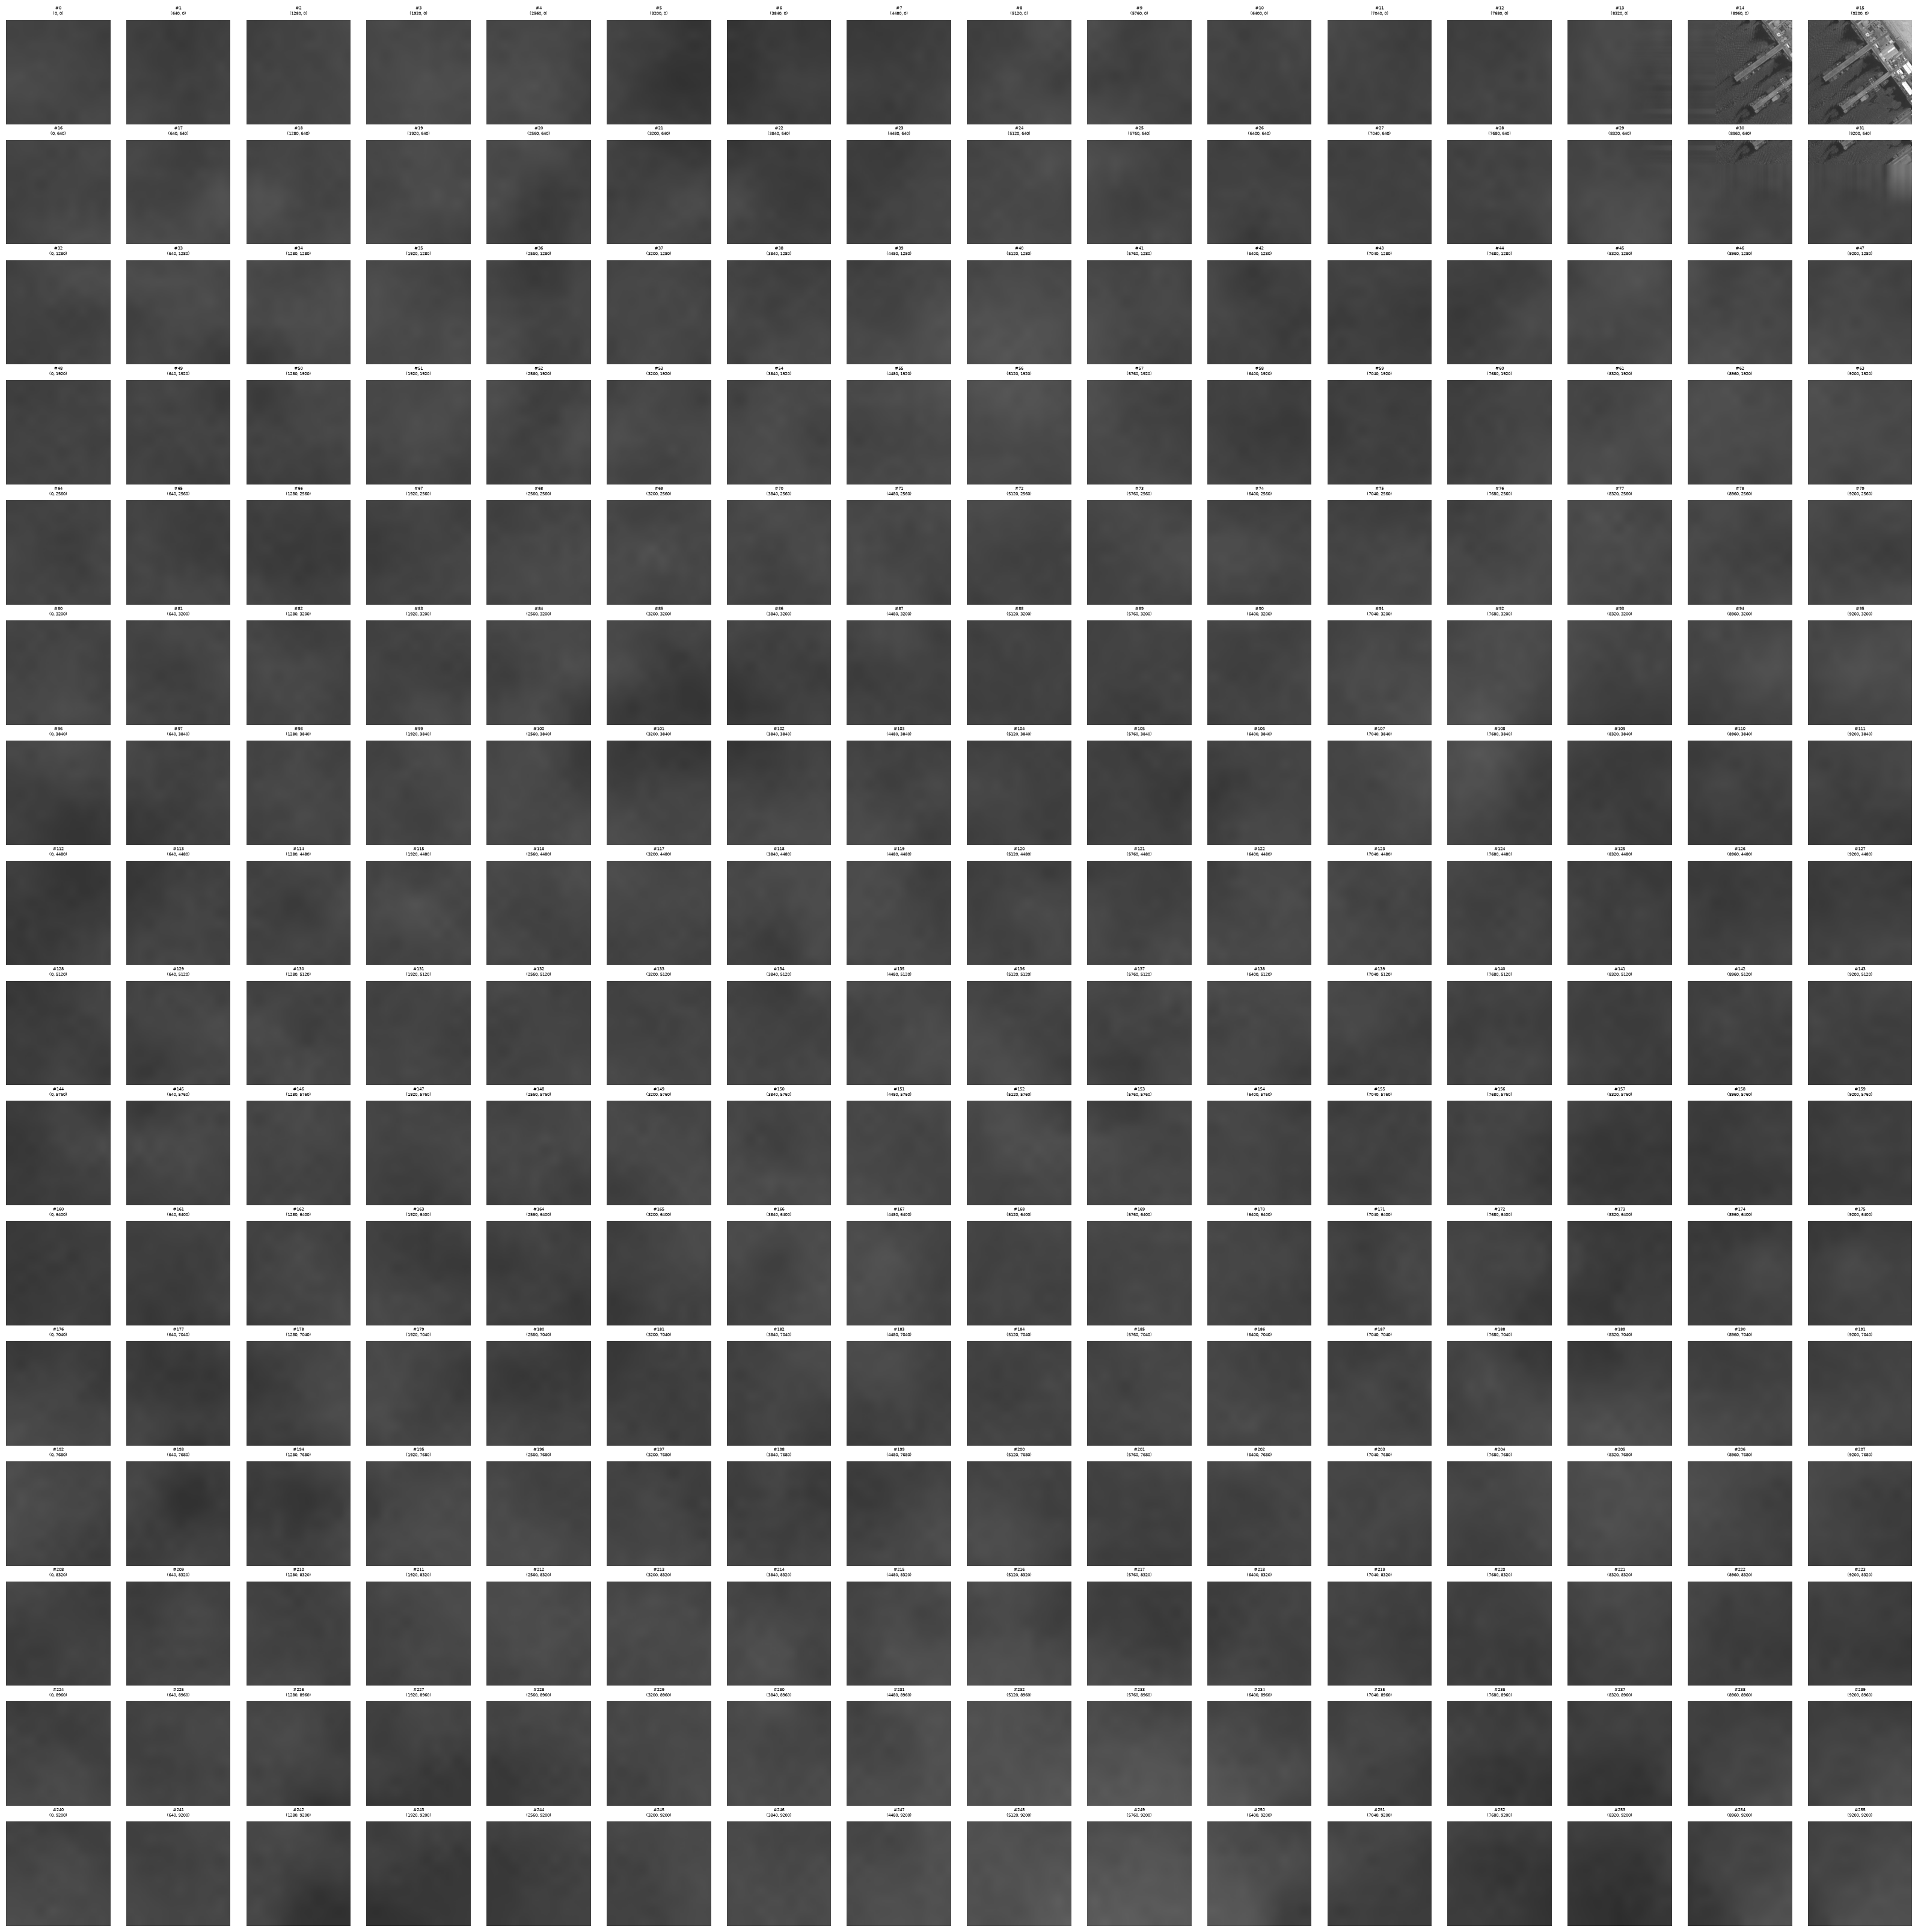

In [4]:
columns = len(x_positions)
rows = math.ceil(len(tile_coordinates) / columns)

with Image.open(image_path) as image:
    fig, axes = plt.subplots(rows, columns, figsize=(32, 32), squeeze=False)
    for ax, info in zip(axes.flat, tile_coordinates):
        tile = image.crop((info["x1"], info["y1"], info["x2"], info["y2"]))
        ax.imshow(tile, cmap="gray", vmin=0, vmax=255)
        ax.set_title(f'#{info["tile_id"]}\n({info["x1"]}, {info["y1"]})', fontsize=5)
        ax.axis("off")
    for ax in axes.flat[len(tile_coordinates):]:
        ax.axis("off")
    plt.tight_layout(pad=0.2)
    plt.show()

In [5]:
from collections.abc import Iterator
from typing import Any


def iter_image_tiles(
    image_path: Path,
    coordinates: list[dict[str, Any]],
) -> Iterator[tuple[Image.Image, dict[str, Any]]]:
    """
    Последовательно извлекает тайлы из изображения.

    В памяти одновременно находится только текущий тайл.
    Исходное изображение открывается один раз на время итерации.
    """
    with Image.open(image_path) as image:
        for tile_info in coordinates:
            crop_box = (
                tile_info["x1"],
                tile_info["y1"],
                tile_info["x2"],
                tile_info["y2"],
            )

            tile = image.crop(crop_box)

            yield tile, tile_info

In [6]:
processed_count = 0

for tile, tile_info in iter_image_tiles(
    image_path,
    tile_coordinates,
):
    assert tile.size == (TILE_SIZE, TILE_SIZE)

    processed_count += 1

    if processed_count <= 3:
        print(
            f'Tile #{tile_info["tile_id"]}: '
            f'size={tile.size}, '
            f'offset=({tile_info["x1"]}, {tile_info["y1"]})'
        )

print(f"Обработано тайлов: {processed_count}")

assert processed_count == len(tile_coordinates)

Tile #0: size=(800, 800), offset=(0, 0)
Tile #1: size=(800, 800), offset=(640, 0)
Tile #2: size=(800, 800), offset=(1280, 0)
Обработано тайлов: 256


In [7]:
def convert_prediction_to_global(
    prediction: dict,
    tile_info: dict,
    image_width: int,
    image_height: int,
) -> dict:
    local_x1, local_y1, local_x2, local_y2 = map(
        float,
        prediction["bbox"],
    )

    if local_x2 <= local_x1 or local_y2 <= local_y1:
        raise ValueError(f"Некорректный bbox: {prediction['bbox']}")

    tile_x = int(tile_info["x1"])
    tile_y = int(tile_info["y1"])

    global_bbox = [
        max(0.0, min(local_x1 + tile_x, image_width)),
        max(0.0, min(local_y1 + tile_y, image_height)),
        max(0.0, min(local_x2 + tile_x, image_width)),
        max(0.0, min(local_y2 + tile_y, image_height)),
    ]

    class_id = int(prediction["class_id"])

    return {
        "tile_id": int(tile_info["tile_id"]),
        "tile_x": tile_x,
        "tile_y": tile_y,
        "local_bbox": [
            local_x1,
            local_y1,
            local_x2,
            local_y2,
        ],
        "global_bbox": global_bbox,
        "class_id": class_id,
        "class_name": prediction.get(
            "class_name",
            detection_model.names[class_id],
        ),
        "confidence": float(prediction["confidence"]),
    }

In [8]:
def collect_predictions(
    image_path: Path,
    tile_coordinates: list[dict],
    predict_tile,
    confidence_threshold: float = 0.25,
) -> list[dict]:
    """
    Последовательно обрабатывает все тайлы и собирает
    предсказания в глобальных координатах.
    """
    all_predictions = []

    with Image.open(image_path) as source:
        image_width, image_height = source.size

    for tile, tile_info in iter_image_tiles(
        image_path,
        tile_coordinates,
    ):
        tile_predictions = predict_tile(tile)

        for prediction in tile_predictions:
            confidence = float(prediction["confidence"])

            if confidence < confidence_threshold:
                continue

            converted_prediction = convert_prediction_to_global(
                prediction=prediction,
                tile_info=tile_info,
                image_width=image_width,
                image_height=image_height,
            )

            all_predictions.append(converted_prediction)

    return all_predictions

In [11]:
import json
import time
from pathlib import Path

import numpy as np
import torch
from PIL import Image, ImageDraw, ImageFont
from ultralytics import YOLO


INPUT_IMAGE_PATH = OUTPUT_PATH

WEIGHTS_PATH = (
    PROJECT_ROOT
    / "runs/YOLO11n/yolo11n_fold1_img800_base_b4w2/"
    "weights/best_0.92475.pt"
)

OUTPUT_IMAGE_PATH = (
    PROJECT_ROOT
    / "data/test/ocean_scene_10000x10000_predictions_before_nms.png"
)

OUTPUT_PREDICTIONS_PATH = (
    PROJECT_ROOT
    / "data/test/ocean_scene_10000x10000_predictions_before_nms.json"
)

OUTPUT_TIMING_PATH = (
    PROJECT_ROOT
    / "data/test/ocean_scene_10000x10000_timing.json"
)

INFERENCE_CONFIDENCE = 0.25
INFERENCE_IOU = 0.70
MAX_DETECTIONS = 300
DEVICE = 0 if torch.cuda.is_available() else "cpu"


def synchronize_device() -> None:
    if torch.cuda.is_available():
        torch.cuda.synchronize()

In [12]:
if not INPUT_IMAGE_PATH.is_file():
    raise FileNotFoundError(
        f"Входное изображение не найдено: {INPUT_IMAGE_PATH}"
    )

if not WEIGHTS_PATH.is_file():
    raise FileNotFoundError(
        f"Веса модели не найдены: {WEIGHTS_PATH}"
    )

# Время начинается до загрузки модели и изображения
pipeline_started_at = time.perf_counter()

detection_model = YOLO(str(WEIGHTS_PATH))

with Image.open(INPUT_IMAGE_PATH) as source:
    image_width, image_height = source.size

# Координаты создаются внутри измеряемого пайплайна
x_positions = calculate_positions(
    image_width,
    TILE_SIZE,
    STRIDE,
)
y_positions = calculate_positions(
    image_height,
    TILE_SIZE,
    STRIDE,
)

tile_coordinates = [
    {
        "tile_id": tile_id,
        "x1": x,
        "y1": y,
        "x2": x + TILE_SIZE,
        "y2": y + TILE_SIZE,
    }
    for tile_id, (y, x) in enumerate(
        (y, x)
        for y in y_positions
        for x in x_positions
    )
]

all_predictions = []
tile_timings = []

for tile_index, (tile, tile_info) in enumerate(
    iter_image_tiles(
        INPUT_IMAGE_PATH,
        tile_coordinates,
    ),
    start=1,
):
    synchronize_device()
    tile_started_at = time.perf_counter()

    result = detection_model.predict(
        source=tile,
        imgsz=TILE_SIZE,
        conf=INFERENCE_CONFIDENCE,
        iou=INFERENCE_IOU,
        max_det=MAX_DETECTIONS,
        device=DEVICE,
        verbose=False,
    )[0]

    synchronize_device()
    tile_finished_at = time.perf_counter()

    tile_timings.append(
        {
            "tile_id": tile_info["tile_id"],
            "seconds": tile_finished_at - tile_started_at,
        }
    )

    if result.boxes is not None and len(result.boxes) > 0:
        boxes = result.boxes.xyxy.detach().cpu().numpy()
        confidences = result.boxes.conf.detach().cpu().numpy()
        class_ids = result.boxes.cls.int().detach().cpu().numpy()

        for box, confidence, class_id in zip(
            boxes,
            confidences,
            class_ids,
        ):
            prediction = {
                "bbox": box.tolist(),
                "class_id": int(class_id),
                "class_name": result.names[int(class_id)],
                "confidence": float(confidence),
            }

            all_predictions.append(
                convert_prediction_to_global(
                    prediction=prediction,
                    tile_info=tile_info,
                    image_width=image_width,
                    image_height=image_height,
                )
            )

    print(
        f"\rТайлы: {tile_index}/{len(tile_coordinates)} "
        f"| боксы: {len(all_predictions)}",
        end="",
    )

synchronize_device()
predictions_ready_at = time.perf_counter()

print()
print(
    "Предсказания получены за:",
    f"{predictions_ready_at - pipeline_started_at:.3f} с",
)

Тайлы: 256/256 | боксы: 28
Предсказания получены за: 7.476 с


In [13]:
OUTPUT_PREDICTIONS_PATH.write_text(
    json.dumps(
        all_predictions,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

print(
    f"Предсказания сохранены: "
    f"{OUTPUT_PREDICTIONS_PATH}"
)

Предсказания сохранены: /home/irdorat/ML_comp/data/test/ocean_scene_10000x10000_predictions_before_nms.json


In [14]:
with Image.open(INPUT_IMAGE_PATH) as source:
    output_image = source.convert("RGB")

draw = ImageDraw.Draw(output_image)

line_width = 12
font_size = 32

try:
    font = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        font_size,
    )
except OSError:
    font = ImageFont.load_default()

color_palette = [
    (255, 64, 64),
    (64, 220, 64),
    (64, 160, 255),
    (255, 200, 64),
    (220, 64, 255),
    (64, 255, 220),
]

for prediction in all_predictions:
    x1, y1, x2, y2 = prediction["global_bbox"]
    class_id = prediction["class_id"]
    class_name = prediction["class_name"]
    confidence = prediction["confidence"]

    color = color_palette[class_id % len(color_palette)]
    label = f"{class_name} {confidence:.2f}"

    draw.rectangle(
        (x1, y1, x2, y2),
        outline=color,
        width=line_width,
    )

    text_box = draw.textbbox(
        (x1, y1),
        label,
        font=font,
    )

    text_width = text_box[2] - text_box[0]
    text_height = text_box[3] - text_box[1]
    label_y = max(0, y1 - text_height - 10)

    draw.rectangle(
        (
            x1,
            label_y,
            x1 + text_width + 12,
            label_y + text_height + 8,
        ),
        fill=color,
    )

    draw.text(
        (x1 + 6, label_y + 2),
        label,
        fill=(0, 0, 0),
        font=font,
    )

output_image.save(
    OUTPUT_IMAGE_PATH,
    format="PNG",
    compress_level=4,
)

pipeline_finished_at = time.perf_counter()

In [15]:
predictions_seconds = (
    predictions_ready_at - pipeline_started_at
)

rendering_and_saving_seconds = (
    pipeline_finished_at - predictions_ready_at
)

total_seconds = (
    pipeline_finished_at - pipeline_started_at
)

tile_seconds = np.asarray(
    [item["seconds"] for item in tile_timings],
    dtype=np.float64,
)

timing_summary = {
    "input_image": str(INPUT_IMAGE_PATH),
    "output_image": str(OUTPUT_IMAGE_PATH),
    "weights": str(WEIGHTS_PATH),
    "image_size": [image_width, image_height],
    "tile_size": TILE_SIZE,
    "overlap": OVERLAP,
    "stride": STRIDE,
    "tile_count": len(tile_coordinates),
    "prediction_count_before_nms": len(all_predictions),
    "seconds_to_predictions": predictions_seconds,
    "rendering_and_saving_seconds": rendering_and_saving_seconds,
    "total_pipeline_seconds": total_seconds,
    "mean_tile_seconds": float(tile_seconds.mean()),
    "median_tile_seconds": float(np.median(tile_seconds)),
    "p95_tile_seconds": float(
        np.percentile(tile_seconds, 95)
    ),
}

OUTPUT_TIMING_PATH.write_text(
    json.dumps(
        timing_summary,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

print("\nРезультат")
print("-" * 50)
print(f"Изображение: {image_width}x{image_height}")
print(f"Тайлов: {len(tile_coordinates)}")
print(f"Боксов до NMS: {len(all_predictions)}")
print(f"Время до предсказаний: {predictions_seconds:.3f} с")
print(
    "Отрисовка и сохранение:",
    f"{rendering_and_saving_seconds:.3f} с",
)
print(f"Полное время: {total_seconds:.3f} с")
print(f"Результат: {OUTPUT_IMAGE_PATH}")
print(f"Метрики: {OUTPUT_TIMING_PATH}")


Результат
--------------------------------------------------
Изображение: 10000x10000
Тайлов: 256
Боксов до NMS: 28
Время до предсказаний: 7.476 с
Отрисовка и сохранение: 7.235 с
Полное время: 14.711 с
Результат: /home/irdorat/ML_comp/data/test/ocean_scene_10000x10000_predictions_before_nms.png
Метрики: /home/irdorat/ML_comp/data/test/ocean_scene_10000x10000_timing.json


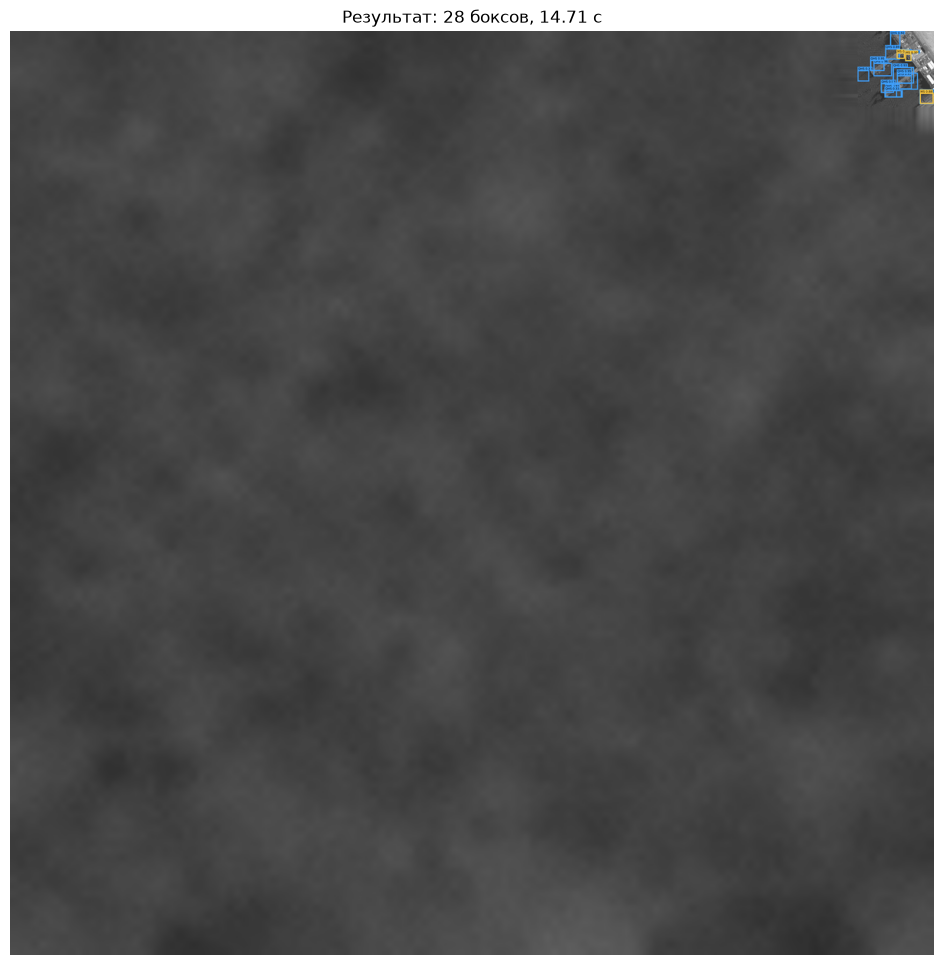

In [16]:
preview = output_image.resize(
    (1200, 1200),
    Image.Resampling.LANCZOS,
)

plt.figure(figsize=(12, 12))
plt.imshow(preview)
plt.title(
    f"Результат: {len(all_predictions)} боксов, "
    f"{total_seconds:.2f} с"
)
plt.axis("off")
plt.show()

In [17]:
from collections import defaultdict


predictions_by_tile = defaultdict(list)

for prediction in all_predictions:
    predictions_by_tile[prediction["tile_id"]].append(
        prediction
    )

detected_tile_ids = sorted(predictions_by_tile)

print(f"Всего тайлов: {len(tile_coordinates)}")
print(f"Тайлов с предсказаниями: {len(detected_tile_ids)}")
print(f"Всего боксов: {len(all_predictions)}")
print(f"ID тайлов с предсказаниями: {detected_tile_ids}")

Всего тайлов: 256
Тайлов с предсказаниями: 4
Всего боксов: 28
ID тайлов с предсказаниями: [14, 15, 30, 31]


In [19]:
columns = len(x_positions)  # 16
rows = math.ceil(len(tile_coordinates) / columns)

with Image.open(image_path) as source:
    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(32, 32),
        squeeze=False,
    )

    for ax, tile_info in zip(
        axes.flat,
        tile_coordinates,
    ):
        tile_id = tile_info["tile_id"]

        tile = source.crop(
            (
                tile_info["x1"],
                tile_info["y1"],
                tile_info["x2"],
                tile_info["y2"],
            )
        )

        tile_predictions = predictions_by_tile.get(
            tile_id,
            [],
        )

        rendered_tile = draw_tile_predictions(
            tile,
            tile_predictions,
        )

        ax.imshow(rendered_tile)

        title_color = "red" if tile_predictions else "black"

        ax.set_title(
            f"#{tile_id} | boxes={len(tile_predictions)}\n"
            f"({tile_info['x1']}, {tile_info['y1']})",
            fontsize=5,
            color=title_color,
        )
        ax.axis("off")

    for ax in axes.flat[len(tile_coordinates):]:
        ax.axis("off")

plt.tight_layout(pad=0.2)
plt.show()

NameError: name 'draw_tile_predictions' is not defined

Error in callback <function flush_figures at 0x76c37816c0e0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 